# M09: Feature Selection
We rank features using multiple methods and select a final feature set for modeling.

### Methods:
1. Correlation with target
2. Mutual Information
3. Random Forest feature importance

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent))
from src.data import load_raw_data
from src.cleaning import clean_data
from src.features import build_features

from sklearn.feature_selection import mutual_info_classif
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")

# Build features (unscaled for interpretability)
df = build_features(clean_data(load_raw_data("../data/raw")), scale=False)
X = df.drop(columns=['Churn'])
y = df['Churn']
print(f"Features: {X.shape[1]}, Samples: {X.shape[0]}")


Features: 35, Samples: 7043


## 1. Correlation with Target

tenure                                  0.352229
InternetService_Fiber optic             0.308020
Contract_Two year                       0.302253
PaymentMethod_Electronic check          0.301919
StreamingTV_No internet service         0.227890
TechSupport_No internet service         0.227890
OnlineBackup_No internet service        0.227890
DeviceProtection_No internet service    0.227890
StreamingMovies_No internet service     0.227890
InternetService_No                      0.227890
OnlineSecurity_No internet service      0.227890
tenure_group_61-72                      0.225500
TotalCharges                            0.198324
MonthlyCharges                          0.193356
AvgChargesPerMonth                      0.193301
dtype: float64


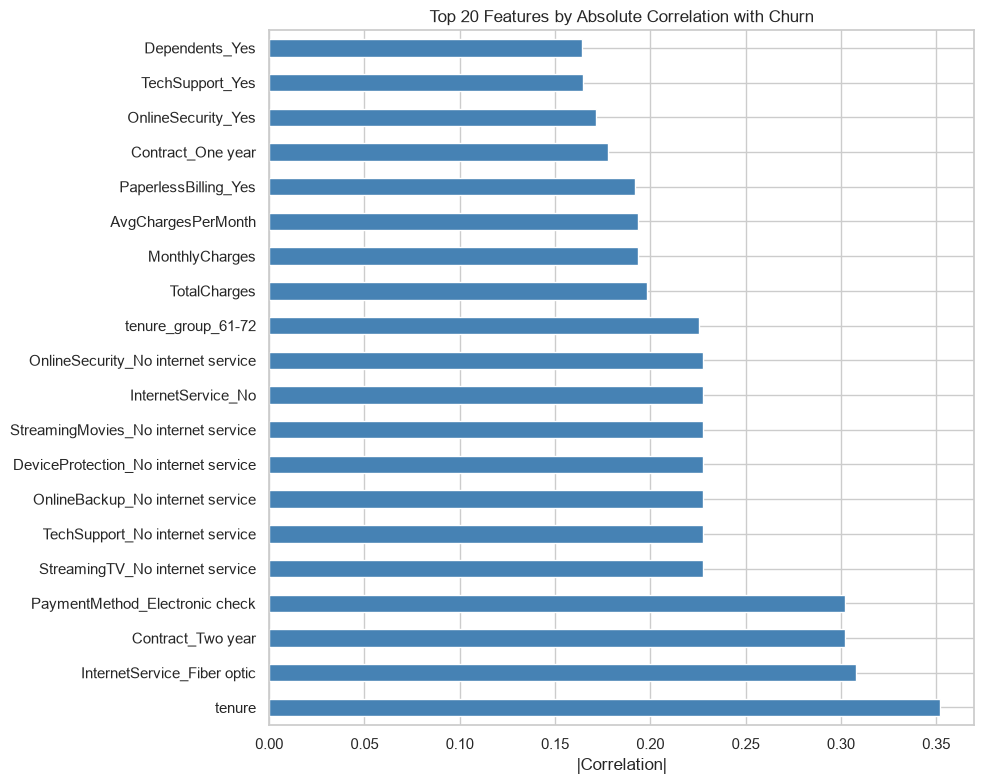

In [2]:
corr_with_target = X.corrwith(y).abs().sort_values(ascending=False)
print(corr_with_target.head(15))

fig, ax = plt.subplots(figsize=(10, 8))
corr_with_target.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 20 Features by Absolute Correlation with Churn')
ax.set_xlabel('|Correlation|')
plt.tight_layout()
plt.show()

## 2. Mutual Information

tenure                                 0.083713
Contract_Two year                      0.059154
MonthlyCharges                         0.048391
TotalCharges                           0.045082
InternetService_Fiber optic            0.042667
StreamingMovies_No internet service    0.036272
AvgChargesPerMonth                     0.035610
tenure_group_61-72                     0.034173
TechSupport_No internet service        0.033205
PaymentMethod_Electronic check         0.031864
OnlineBackup_No internet service       0.030252
OnlineSecurity_No internet service     0.028732
StreamingTV_No internet service        0.028215
OnlineSecurity_Yes                     0.025825
InternetService_No                     0.023668
dtype: float64


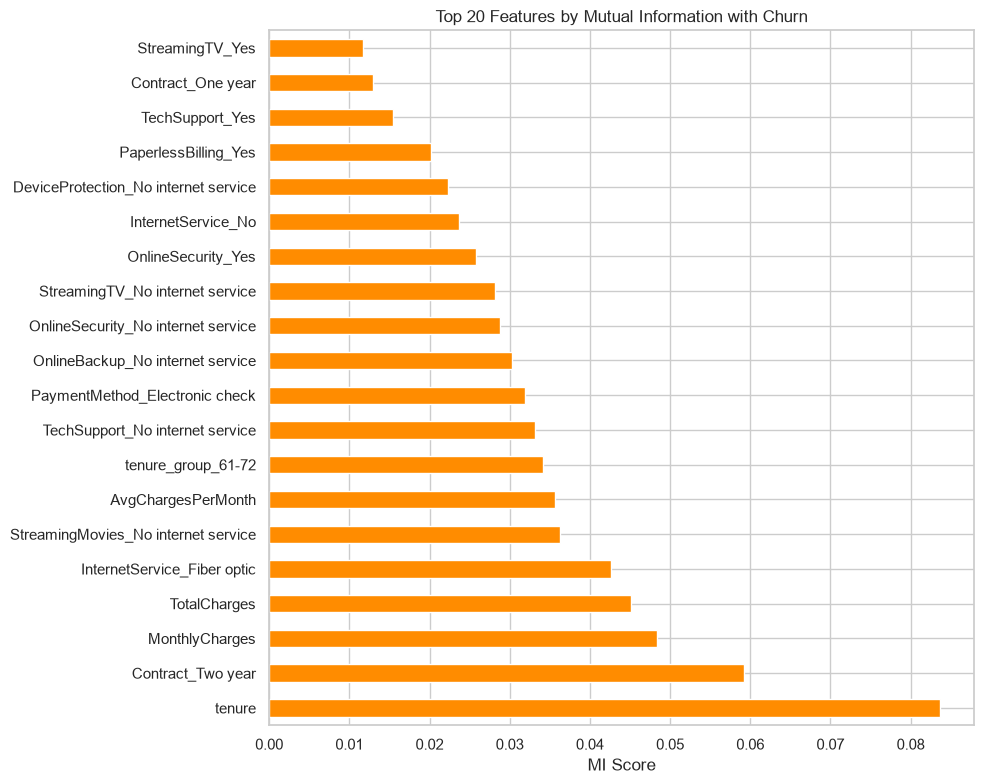

In [3]:
mi = mutual_info_classif(X, y, random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series.head(15))

fig, ax = plt.subplots(figsize=(10, 8))
mi_series.head(20).plot(kind='barh', ax=ax, color='darkorange')
ax.set_title('Top 20 Features by Mutual Information with Churn')
ax.set_xlabel('MI Score')
plt.tight_layout()
plt.show()

## 3. Random Forest Feature Importance

TotalCharges                      0.156228
tenure                            0.137891
AvgChargesPerMonth                0.131670
MonthlyCharges                    0.130282
PaymentMethod_Electronic check    0.033747
InternetService_Fiber optic       0.031321
Contract_Two year                 0.029262
gender_Male                       0.024311
OnlineSecurity_Yes                0.023679
PaperlessBilling_Yes              0.023203
Contract_One year                 0.021620
TechSupport_Yes                   0.021444
Partner_Yes                       0.019919
SeniorCitizen                     0.018310
OnlineBackup_Yes                  0.018161
dtype: float64


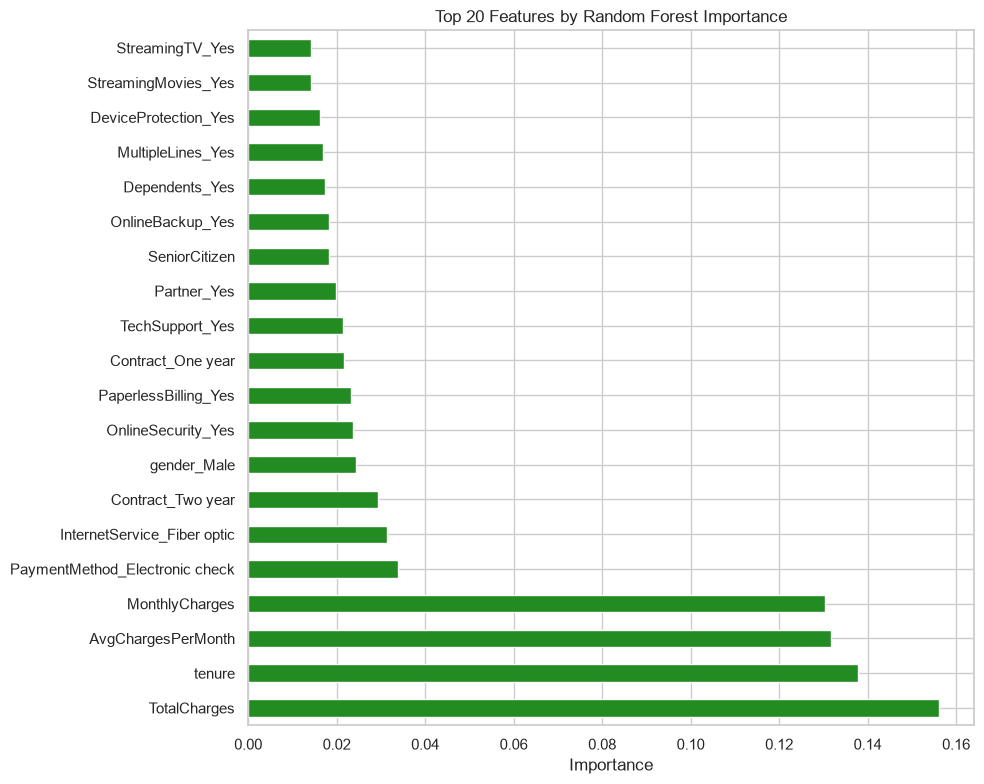

In [4]:
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X, y)
rf_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
print(rf_imp.head(15))

fig, ax = plt.subplots(figsize=(10, 8))
rf_imp.head(20).plot(kind='barh', ax=ax, color='forestgreen')
ax.set_title('Top 20 Features by Random Forest Importance')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

## 4. Summary & Feature Selection Decision

### Consensus Top Features (appearing in top 15 across all 3 methods):
- **Contract_Two year / Contract_One year** — strongest predictor across all methods
- **tenure** — highly correlated with churn; loyal customers stay
- **MonthlyCharges / TotalCharges / AvgChargesPerMonth** — pricing is a key driver
- **InternetService_Fiber optic** — fiber customers churn more
- **OnlineSecurity_Yes / TechSupport_Yes** — sticky add-on services
- **PaymentMethod_Electronic check** — electronic check = high churn risk

### Decision:
We will keep **all features** for modeling rather than dropping any. The tree-based models (RF, XGBoost, LightGBM, CatBoost) handle irrelevant features gracefully, and the linear models (LR, SVM) benefit from the regularization we'll apply. Dropping features risks losing signal with minimal upside at this dataset size (~7k rows, ~30 features).